# Lab 2: Classification Using KNN and RNN Algorithms

**Student Name:** Abhilash Reddy Marthala  
**Course:** MSCS 634  
**Assignment:** Lab 2 – Classification Using KNN and RNN Algorithms  
**Dataset:** Wine Dataset from Scikit-learn

## Purpose

The purpose of this lab is to implement and compare the K-Nearest Neighbors (KNN) and Radius Neighbors (RNN) classification algorithms using the Wine Dataset. The lab examines how different values of k and radius affect classification accuracy.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Wine Dataset
wine = load_wine()

# Create a DataFrame with the feature values
wine_df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Add the target class
wine_df["target"] = wine.target

print("Wine Dataset loaded successfully.")
print("Dataset shape:", wine_df.shape)

display(wine_df.head())

Wine Dataset loaded successfully.
Dataset shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
print("Feature names:")
print(wine.feature_names)

print("\nTarget class names:")
print(wine.target_names)

print("\nDataset information:")
wine_df.info()

print("\nDescriptive statistics:")
display(wine_df.describe())

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target class names:
['class_0' 'class_1' 'class_2']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocya

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [4]:
print("Missing values in each column:")
display(wine_df.isnull().sum())

Missing values in each column:


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [5]:
class_distribution = wine_df["target"].value_counts().sort_index()

class_distribution_df = pd.DataFrame({
    "Class Number": class_distribution.index,
    "Class Name": [
        wine.target_names[i]
        for i in class_distribution.index
    ],
    "Number of Samples": class_distribution.values
})

display(class_distribution_df)

,Class Number,Class Name,Number of Samples
0,0,class_0,59
1,1,class_1,71
2,2,class_2,48


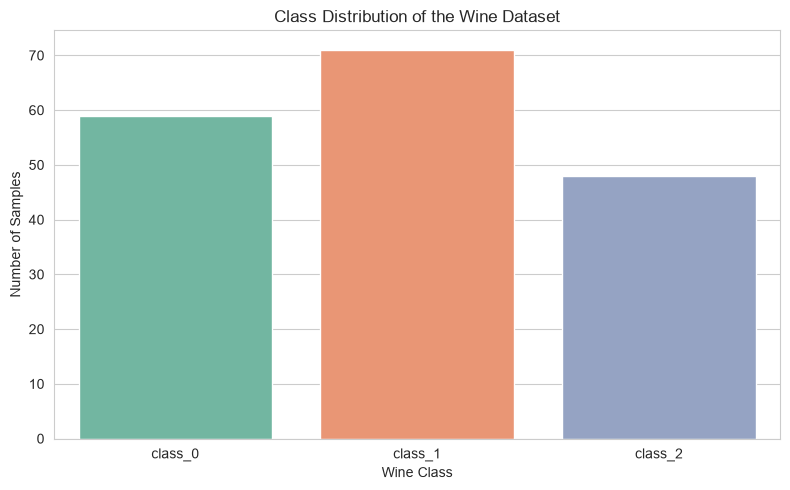

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=wine_df,
    x="target",
    hue="target",
    palette="Set2",
    legend=False
)

plt.title("Class Distribution of the Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(
    ticks=[0, 1, 2],
    labels=wine.target_names
)

plt.tight_layout()
plt.show()

## Dataset Exploration

The Wine Dataset contains 178 observations, 13 numerical input features, and three target classes. The features represent different chemical properties of wine, including alcohol, malic acid, magnesium, flavanoids, color intensity, and proline.

The class distribution is reasonably balanced:

- Class 0 (`class_0`): 59 samples
- Class 1 (`class_1`): 71 samples
- Class 2 (`class_2`): 48 samples

The dataset does not contain any missing values.

In [7]:
# Separate features and target
X = wine.data
y = wine.target

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature set:", X_train.shape)
print("Testing feature set:", X_test.shape)
print("Training target set:", y_train.shape)
print("Testing target set:", y_test.shape)

Training feature set: (142, 13)
Testing feature set: (36, 13)
Training target set: (142,)
Testing target set: (36,)


## K-Nearest Neighbors (KNN) Classification

KNN classifies a test observation based on the classes of its nearest training observations. The parameter k determines how many neighbors are considered. In this experiment, the model is evaluated using k values of 1, 5, 11, 15, and 21.

In [8]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    # Create the KNN model
    knn_model = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn_model.fit(X_train, y_train)

    # Predict the test data
    knn_predictions = knn_model.predict(X_test)

    # Calculate and store accuracy
    accuracy = accuracy_score(y_test, knn_predictions)
    knn_accuracies.append(accuracy)

    print(f"k = {k:2d} | Accuracy = {accuracy:.4f}")

k =  1 | Accuracy = 0.7778
k =  5 | Accuracy = 0.8056
k = 11 | Accuracy = 0.8056
k = 15 | Accuracy = 0.8056
k = 21 | Accuracy = 0.8056


In [9]:
knn_results = pd.DataFrame({
    "K Value": k_values,
    "Accuracy": knn_accuracies
})

display(knn_results)

,K Value,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


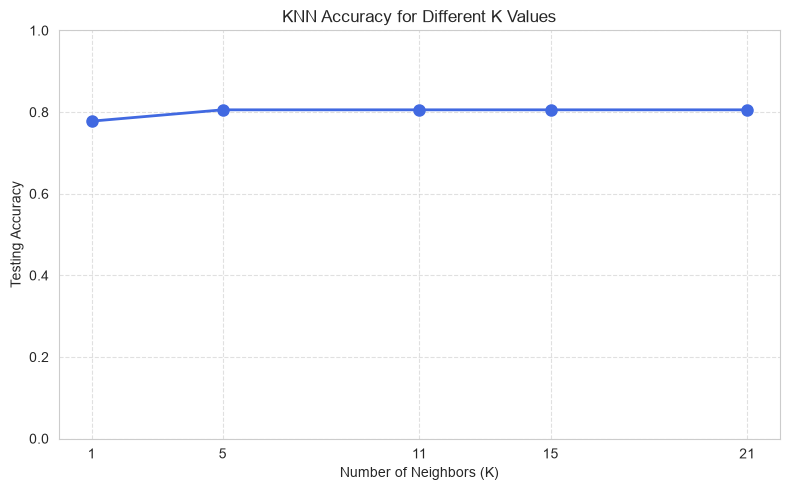

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    knn_accuracies,
    marker="o",
    linewidth=2,
    markersize=8,
    color="royalblue"
)

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Testing Accuracy")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## KNN Observations

The KNN classifier achieved an accuracy of approximately 77.78% when k was 1. Its accuracy increased to approximately 80.56% when k was 5. The accuracy remained stable for k values of 11, 15, and 21.

A very small k value can make the model sensitive to individual observations and noise. Among the tested values, k = 5 is a reasonable choice because it achieved the highest observed accuracy while using fewer neighbors than the other values with the same accuracy.


## Radius Neighbors (RNN) Classification

The Radius Neighbors classifier considers all training observations located within a specified distance, or radius, of a test observation. Unlike KNN, the number of neighbors can vary for each observation. This experiment evaluates radius values of 350, 400, 450, 500, 550, and 600.


In [11]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for radius in radius_values:
    # Create the RNN model
    rnn_model = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label="most_frequent"
    )

    # Train the model
    rnn_model.fit(X_train, y_train)

    # Predict the test data
    rnn_predictions = rnn_model.predict(X_test)

    # Calculate and store accuracy
    accuracy = accuracy_score(y_test, rnn_predictions)
    rnn_accuracies.append(accuracy)

    print(
        f"Radius = {radius:3d} | "
        f"Accuracy = {accuracy:.4f}"
    )

Radius = 350 | Accuracy = 0.7222
Radius = 400 | Accuracy = 0.6944
Radius = 450 | Accuracy = 0.6944
Radius = 500 | Accuracy = 0.6944
Radius = 550 | Accuracy = 0.6667
Radius = 600 | Accuracy = 0.6667


In [12]:
rnn_results = pd.DataFrame({
    "Radius": radius_values,
    "Accuracy": rnn_accuracies
})

display(rnn_results)

,Radius,Accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


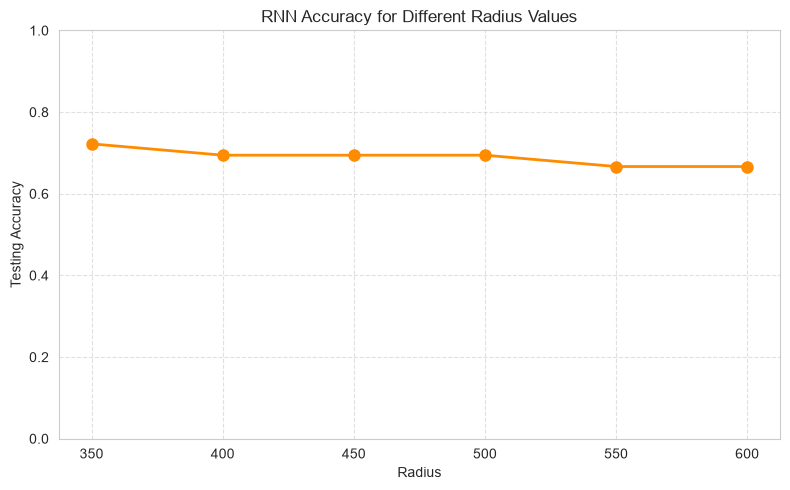

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    radius_values,
    rnn_accuracies,
    marker="o",
    linewidth=2,
    markersize=8,
    color="darkorange"
)

plt.title("RNN Accuracy for Different Radius Values")
plt.xlabel("Radius")
plt.ylabel("Testing Accuracy")
plt.xticks(radius_values)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## RNN Observations

The RNN classifier achieved its highest accuracy of approximately 72.22% when the radius was 350. Accuracy decreased as the radius increased. Radius values of 550 and 600 produced the lowest accuracy of approximately 66.67%.

A larger radius includes more training observations in each prediction. When the radius becomes too large, observations from different classes may be included in the same neighborhood. This can make the model less effective at distinguishing between the three wine classes.

The `outlier_label="most_frequent"` setting was used so that a test observation without any neighbors inside the selected radius could be assigned the most frequent training class instead of generating an error.

In [14]:
# Find the best KNN parameter and accuracy
best_k_index = knn_accuracies.index(max(knn_accuracies))
best_k = k_values[best_k_index]
best_knn_accuracy = knn_accuracies[best_k_index]

# Find the best RNN parameter and accuracy
best_radius_index = rnn_accuracies.index(max(rnn_accuracies))
best_radius = radius_values[best_radius_index]
best_rnn_accuracy = rnn_accuracies[best_radius_index]

# Create a comparison table
comparison = pd.DataFrame({
    "Model": ["KNN", "RNN"],
    "Best Parameter": [
        f"k = {best_k}",
        f"radius = {best_radius}"
    ],
    "Best Accuracy": [
        best_knn_accuracy,
        best_rnn_accuracy
    ]
})

display(comparison)

print(
    f"Best KNN: k = {best_k}, "
    f"accuracy = {best_knn_accuracy:.4f}"
)

print(
    f"Best RNN: radius = {best_radius}, "
    f"accuracy = {best_rnn_accuracy:.4f}"
)

,Model,Best Parameter,Best Accuracy
0,KNN,k = 5,0.805556
1,RNN,radius = 350,0.722222


Best KNN: k = 5, accuracy = 0.8056
Best RNN: radius = 350, accuracy = 0.7222


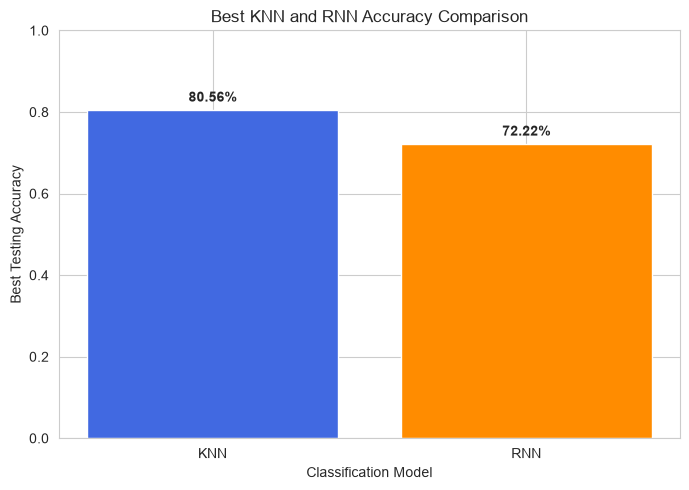

In [15]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    comparison["Model"],
    comparison["Best Accuracy"],
    color=["royalblue", "darkorange"]
)

plt.title("Best KNN and RNN Accuracy Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Best Testing Accuracy")
plt.ylim(0, 1)

for bar, accuracy in zip(
    bars,
    comparison["Best Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{accuracy:.2%}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Model Comparison and Conclusion

Based on the tested parameter values, KNN performed better than RNN. The best KNN model achieved an accuracy of approximately 80.56% with k = 5, while the best RNN model achieved approximately 72.22% accuracy with a radius of 350.

KNN produced relatively stable results after k increased from 1 to 5. In contrast, RNN accuracy generally decreased as the radius increased. Larger radius values may include observations from different wine classes, reducing the classifier's ability to separate the classes.

### When KNN May Be Preferred

KNN may be preferable when:

- A fixed number of neighbors should participate in every prediction.
- The data density varies across the feature space.
- It is difficult to select an appropriate distance radius.
- A simple and predictable neighborhood size is preferred.

### When RNN May Be Preferred

RNN may be preferable when:

- Only observations within a meaningful distance should affect a prediction.
- The dataset has relatively consistent density.
- The distance threshold has a practical or domain-specific meaning.
- The number of nearby observations should be allowed to vary.

### Final Conclusion

For this experiment, KNN was the better-performing classification model. A value of k = 5 achieved the highest KNN accuracy among the tested values. For RNN, a radius of 350 achieved the highest accuracy, but it still performed below the best KNN result.

The original feature values were retained because the assigned RNN radius values of 350 through 600 correspond to the unscaled Wine Dataset. Standardizing the features would change the meaning of these radius values.

This experiment demonstrates that parameter selection has a significant effect on classification accuracy.